<a href="https://colab.research.google.com/github/DIVYA-SAKHARKAR/uber-data-analysis/blob/main/Uber_Ride_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#load dataset
df=pd.read_csv('uber.csv')

#Initial Data Exploration
print(df.head())
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

   Unnamed: 0                            key  fare_amount  \
0    24238194    2015-05-07 19:52:06.0000003          7.5   
1    27835199    2009-07-17 20:04:56.0000002          7.7   
2    44984355   2009-08-24 21:45:00.00000061         12.9   
3    25894730    2009-06-26 08:22:21.0000001          5.3   
4    17610152  2014-08-28 17:47:00.000000188         16.0   

           pickup_datetime  pickup_longitude  pickup_latitude  \
0  2015-05-07 19:52:06 UTC        -73.999817        40.738354   
1  2009-07-17 20:04:56 UTC        -73.994355        40.728225   
2  2009-08-24 21:45:00 UTC        -74.005043        40.740770   
3  2009-06-26 08:22:21 UTC        -73.976124        40.790844   
4  2014-08-28 17:47:00 UTC        -73.925023        40.744085   

   dropoff_longitude  dropoff_latitude  passenger_count  
0         -73.999512         40.723217              1.0  
1         -73.994710         40.750325              1.0  
2         -73.962565         40.772647              1.0  
3         

#data cleaning

In [ ]:
df=df.dropna()
df.shape

(35724, 9)

#Feature Engineering & Data Cleaning

In [ ]:
df['pickup_datetime']=pd.to_datetime(df['pickup_datetime'])

df['hour']=df['pickup_datetime'].dt.hour
df['day']=df['pickup_datetime'].dt.day_name()
df['month']=df['pickup_datetime'].dt.month
df['year']=df['pickup_datetime'].dt.year

df=df[df['fare_amount']>0]
df=df[df['passenger_count']>0]

print(df.shape)
print(df.dtypes)
print(df.head())

(35601, 13)
Unnamed: 0                         int64
key                               object
fare_amount                      float64
pickup_datetime      datetime64[ns, UTC]
pickup_longitude                 float64
pickup_latitude                  float64
dropoff_longitude                float64
dropoff_latitude                 float64
passenger_count                  float64
hour                               int32
day                               object
month                              int32
year                               int32
dtype: object
   Unnamed: 0                            key  fare_amount  \
0    24238194    2015-05-07 19:52:06.0000003          7.5   
1    27835199    2009-07-17 20:04:56.0000002          7.7   
2    44984355   2009-08-24 21:45:00.00000061         12.9   
3    25894730    2009-06-26 08:22:21.0000001          5.3   
4    17610152  2014-08-28 17:47:00.000000188         16.0   

            pickup_datetime  pickup_longitude  pickup_latitude  \
0 2015-0

#Exploratory Data Analysis (EDA)

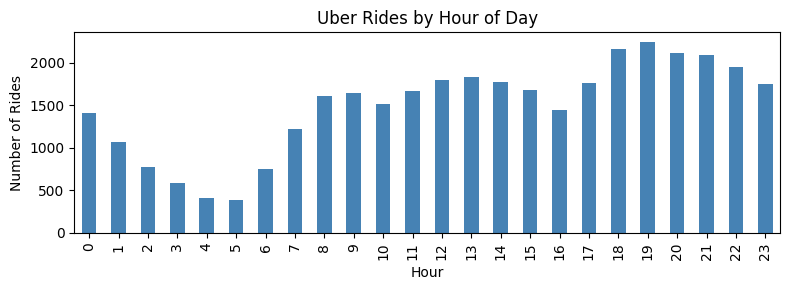

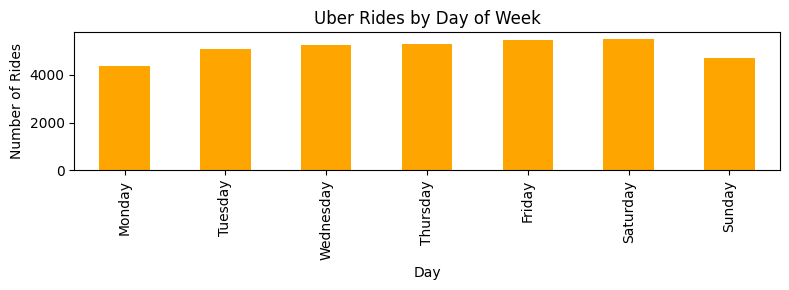

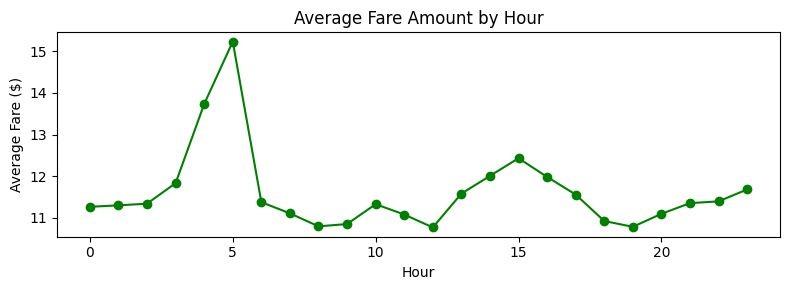

In [ ]:
# 1. Peak hours - when are most rides taken?
plt.figure(figsize=(8,3))
df['hour'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Uber Rides by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Rides')
plt.tight_layout()
plt.show()

# 2. Busiest day of the week
plt.figure(figsize=(8,3))
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['day'].value_counts().reindex(day_order).plot(kind='bar', color='orange')
plt.title('Uber Rides by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Rides')
plt.tight_layout()
plt.show()

# 3. Average fare by hour
plt.figure(figsize=(8,3))
df.groupby('hour')['fare_amount'].mean().plot(kind='line', color='green', marker='o')
plt.title('Average Fare Amount by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Fare ($)')
plt.tight_layout()
plt.show()

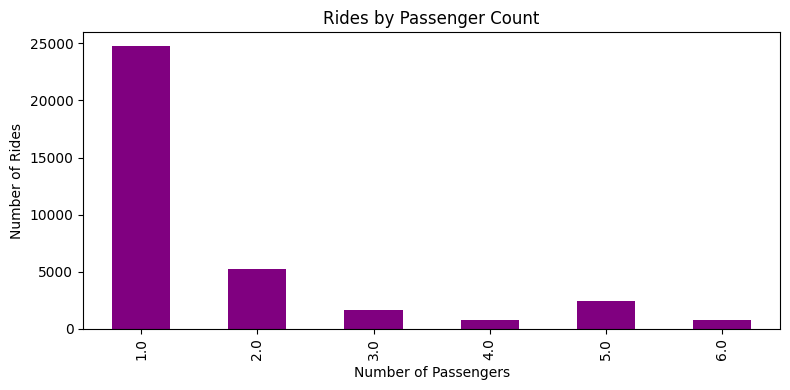

Average fare: $ 11.4
Max fare: $ 350.0
Most common hour: 19
Most common day: Saturday


In [ ]:
# 4. Most common passenger count
plt.figure(figsize=(8,4))
df['passenger_count'].value_counts().sort_index().plot(kind='bar', color='purple')
plt.title('Rides by Passenger Count')
plt.xlabel('Number of Passengers')
plt.ylabel('Number of Rides')
plt.tight_layout()
plt.show()

# Summary statistics
print("Average fare: $", round(df['fare_amount'].mean(), 2))
print("Max fare: $", round(df['fare_amount'].max(), 2))
print("Most common hour:", df['hour'].mode()[0])
print("Most common day:", df['day'].mode()[0])

#KEY INSIGHTS
- Peak ride demand is observed during 6 PM – 9 PM
- Friday and Saturday show higher ride activity
- Most rides are taken by 1–2 passengers
- Average fare is approximately $12, with maximum fare reaching upto 50 dollar
- Demand increases during evening hours, affecting pricing trends

In [ ]:
df.to_csv('uber_cleaned.csv',index=False)